In [86]:
library(readr)
library(dplyr)
source("../../Common/func.R")

In [87]:
# Read CSV file
FRG <- read_csv("../../../data/NaturalGas_WHG.csv", show_col_types = FALSE)
# Summary of the data
glimpse(FRG)

Rows: 1,051,200
Columns: 4
$ unix_ts   <dbl> 1333263600, 1333263660, 1333263720, 1333263780, 1333263840, …
$ counter   <dbl> 559900, 559900, 559900, 559900, 559900, 559900, 559900, 5599…
$ avg_rate  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ inst_rate <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


In [88]:
# Convert unix timestamp (int) column to readable/usable columns
FRG <- convert_timeStamp(FRG, "unix_ts") %>%
    mutate(avg_rate_modif = avg_rate / 60)

In [89]:
# Compute the average yearly consumption of natural gas (meter squared)
FRG_Total_Consumption <- yearly_consumption(FRG, "avg_rate_modif")
# Display the result
FRG_Total_Consumption %>%
    mutate(JG = yearly_consumption_v2 * 0.0373)

nDays,total_consumption,yearly_consumption_v1,yearly_consumption_v2,JG
<int>,<dbl>,<dbl>,<dbl>,<dbl>
731,2469.175,1232.899,1234.588,46.05011


## Temperature & Natural Gas - Correlation

In [90]:
temp <- read_csv("../../../data/Climate_HourlyWeather.csv", show_col_types = FALSE) %>%
    select(`Date/Time`, `Temp (C)`, `Data Quality`, `Temp Flag`) %>%
    rename(timeStamp = `Date/Time`)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [109]:
FRGHourly <- FRG %>%
    group_by(year, month, day, hour) %>%
    summarise(
        unix_ts = first(unix_ts),
        timeStamp = first(timeStamp),
        consumption = sum(avg_rate) / 60
    )

`summarise()` has grouped output by 'year', 'month', 'day'. You can override
using the `.groups` argument.


In [110]:
FRG_Temp <- FRGHourly %>%
    left_join(temp, by = c("timeStamp"), suffix = c("_gas", "_temp"))

head(FRG_Temp, 5)

year,month,day,hour,unix_ts,timeStamp,consumption,Temp (C),Data Quality,Temp Flag
<chr>,<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<lgl>
2012,04,01,15,1333263600,2012-04-01 19:00:00,0,8.4,NA,NA
2012,04,01,16,1333267200,2012-04-01 20:00:00,0,7.9,NA,NA
2012,04,01,17,1333270800,2012-04-01 21:00:00,0,7.2,NA,NA
2012,04,01,18,1333274400,2012-04-01 22:00:00,0,6.6,NA,NA
2012,04,01,19,1333278000,2012-04-01 23:00:00,25,6.8,NA,NA


In [93]:
library(ggplot2)

In [159]:
FRG_Temp_int <- FRG_Temp %>%
    mutate(
        year = as.integer(year),
        month = as.integer(month),
        day = as.integer(day),
        hour = factor(as.integer(hour)),
        intTime = as.integer(format(timeStamp, "%H")),
        instant = (unix_ts)/86400
    )

In [160]:
head(FRG_Temp_int, 5)

year,month,day,hour,unix_ts,timeStamp,consumption,Temp (C),Data Quality,Temp Flag,intTime,instant
<int>,<int>,<int>,<fct>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<dbl>
2012,4,1,15,1333263600,2012-04-01 19:00:00,0,8.4,NA,NA,19,15431.29
2012,4,1,16,1333267200,2012-04-01 20:00:00,0,7.9,NA,NA,20,15431.33
2012,4,1,17,1333270800,2012-04-01 21:00:00,0,7.2,NA,NA,21,15431.38
2012,4,1,18,1333274400,2012-04-01 22:00:00,0,6.6,NA,NA,22,15431.42
2012,4,1,19,1333278000,2012-04-01 23:00:00,25,6.8,NA,NA,23,15431.46


In [161]:
FRG_Temp_int %>% 
    filter(year == 2013, month == 1) %>%
    mutate(test = instant - min(instant))%>%
    arrange(desc(instant))

year,month,day,hour,unix_ts,timeStamp,consumption,Temp (C),Data Quality,Temp Flag,intTime,instant,test
<int>,<int>,<int>,<fct>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<dbl>,<dbl>
2013,1,31,23,1359648000,2013-02-01 04:00:00,0,6.1,NA,NA,4,15736.67,0.95833333
2013,1,31,22,1359644400,2013-02-01 03:00:00,225,6.2,NA,NA,3,15736.62,0.91666667
2013,1,31,21,1359640800,2013-02-01 02:00:00,0,6.5,NA,NA,2,15736.58,0.87500000
2013,1,31,20,1359637200,2013-02-01 01:00:00,0,6.8,NA,NA,1,15736.54,0.83333333
2013,1,31,19,1359633600,2013-02-01 00:00:00,0,6.7,NA,NA,0,15736.50,0.79166667
2013,1,31,18,1359630000,2013-01-31 23:00:00,0,7.3,NA,NA,23,15736.46,0.75000000
2013,1,31,17,1359626400,2013-01-31 22:00:00,0,6.9,NA,NA,22,15736.42,0.70833333
2013,1,31,16,1359622800,2013-01-31 21:00:00,0,7.6,NA,NA,21,15736.38,0.66666667
2013,1,31,15,1359619200,2013-01-31 20:00:00,0,7.6,NA,NA,20,15736.33,0.62500000


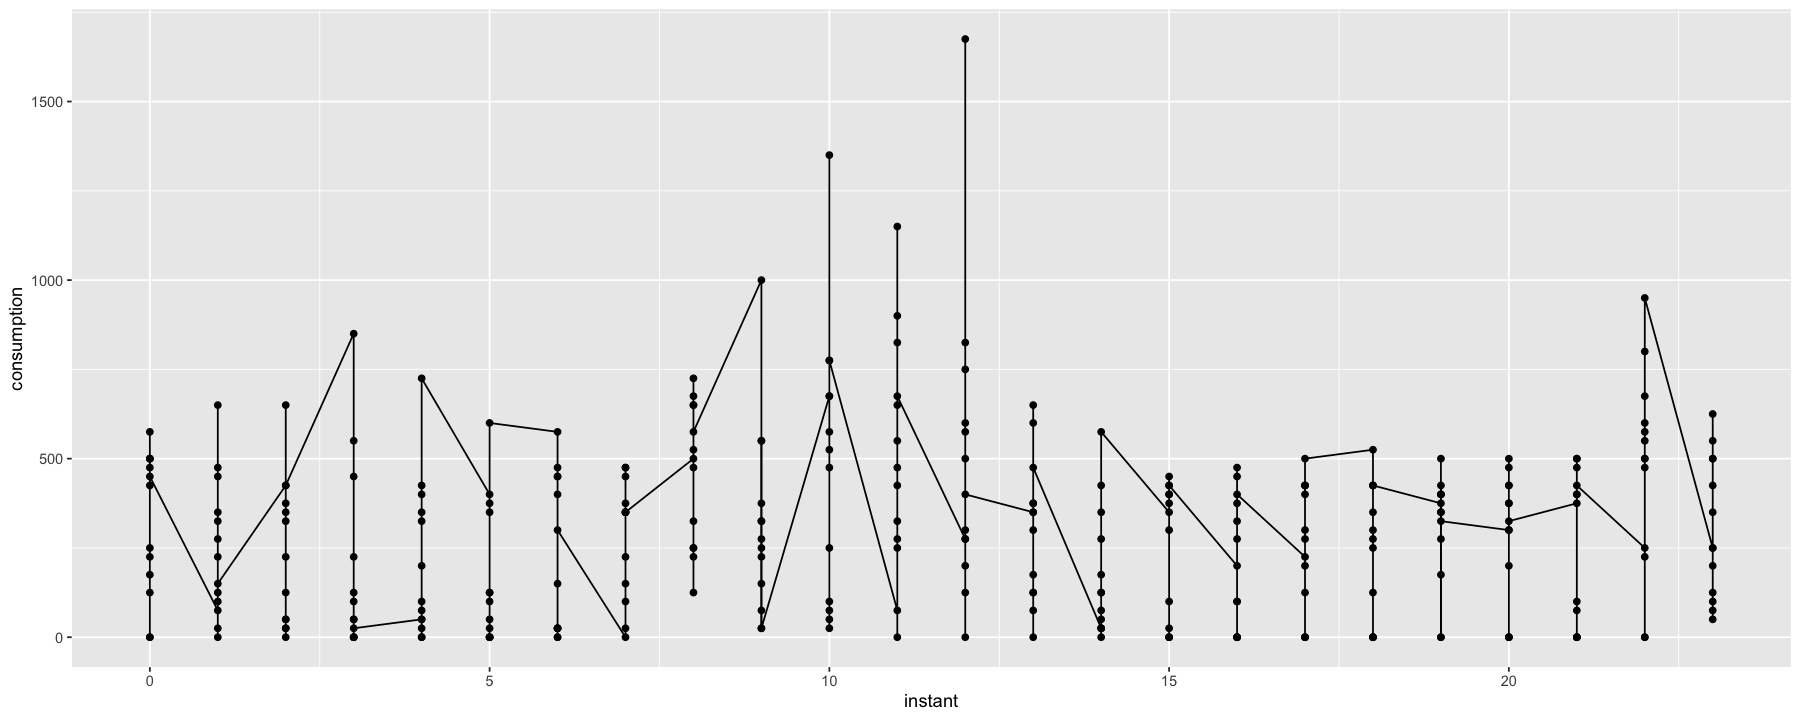

In [141]:
options(repr.plot.width = 15, repr.plot.height = 6)
FRG_Temp_int %>%
    filter(year == 2013, month == 1) %>%
    filter(day < 14) %>%
    ggplot(aes(x = instant, y = consumption, group = 1)) +
        geom_point() +
        geom_line() 
        #+ scale_x_continuous("Day", breaks = 0:14, labels = 0:14)
